In [1]:
import pandas as pd 
from pathlib import Path
import numpy as np 
import torch 
from IPython.display import display, Audio
from corpus.speech_and_texture_test import SpeechAndTextureTestSet
import h5py
import src.audio_transforms as at
from tqdm import tqdm

In [3]:
def db_to_rms(db):
    return np.power(10,(db/20)) * 20e-6

## Write a function using pytorch to apply a time delay between the left and right channels of a set of stereo audio files
def apply_time_delay(audio, delay_ms, sample_rate=44100):
    """
    Apply a time delay to the left and right channels of a stereo audio file.
    
    Parameters:
    - audio: A 2D numpy array of shape (2, N) where N is the number of samples.
    - delay: The time delay in seconds to apply to the left channel.
    - sample_rate: The sample rate of the audio file (default is 44100 Hz).
    
    Returns:
    - A 2D numpy array with the same shape as the input audio, with the time delay applied.
    """
    # Convert delay from seconds to samples
    delay = delay_ms / 1000.0
    delay_samples = int(delay * sample_rate)  
    left_channel = audio[0]
    right_channel = audio[1]
    
    # Create a new array to hold the delayed audio
    delayed_audio = np.zeros_like(audio)
    
    # Apply the time delay
    delayed_audio[0] = np.concatenate((np.zeros(delay_samples), left_channel[:-delay_samples]))
    delayed_audio[1] = right_channel
    
    return delayed_audio





    

In [2]:

from corpus.binaural_swc_currated_pd import SWCHumanExperimentStimDataset

print("Using textures as background noise")
texture_dataset = SpeechAndTextureTestSet(file_path='/om/user/imgriff/datasets/speech_in_synthetic_textures/separated_sources/stim.hdf5',
                    separated_signals=True,
                    symmetric_distractor=False) # only need one 
# texture_ix = np.random.randint(len(texture_dataset))
_, _, texture_signal, _, texture_label = texture_dataset[0]

model_in_sr = 44100
dataset = SWCHumanExperimentStimDataset(path='/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl',
                                        run_all_stim=True,
                                        sr=model_in_sr)
    # elif args.texture_distractor:
cue, fg, bg, bg_2, label, dist_word_label, dist_word_label2, stim_ixs = dataset[0]

Using textures as background noise


In [11]:
target = torch.from_numpy(fg).unsqueeze(0).float()
target.repeat(1,2,1).shape

torch.Size([1, 2, 132300])

In [ ]:
#### Scene gen proceedure 1: manually set levels, spatialize, then mix

## init noise as white noise with same duration as target 
signal_db = 60 
rms_level = db_to_rms(signal_db)
set_level = at.BinauralRMSNormalizeForegroundAndBackground(rms_level)

noise = torch.randn(1, 2, len(fg))

target = torch.from_numpy(fg).unsqueeze(0).float()
# duplicate along dim 1 
target = target.repeat(1, 2, 1)

print("Target")
display(Audio(target.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
print("distractor 1")
display(Audio(dist_1.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
print("distractor 2")
display(Audio(dist_2.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
print("Texture")
display(Audio(spatial_texture.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
print("Mixture")
display(Audio(manual_mixture.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))

RuntimeError: shape '[110250, 1, 1, -1]' is invalid for input of size 132299

In [9]:
### Same but using audio transforms 

dist_rms = db_to_rms(65) # transform should normalize sum to 65 

target_rms = torch.sqrt(torch.mean(torch.pow(manual_mixture, 2))) #### Set target mixture to RMS of manual mixture for comparison 

audio_transforms_0_db = at.AudioCompose([
                    at.AudioToTensor(),
                    at.BinauralCombineWithRandomDBSNR(low_snr=0,    # is 0 dB
                                                    high_snr=0), # is 0 dB 
                    at.BinauralRMSNormalizeForegroundAndBackground(rms_level=dist_rms), 
            ]).cuda()

audio_transforms_test_db = at.AudioCompose([
                at.AudioToTensor(),
                at.BinauralCombineWithRandomDBSNR(low_snr=SNR,    
                                                high_snr=SNR), 
                at.BinauralRMSNormalizeForegroundAndBackground(rms_level=target_rms)
        ]).cuda()

# this stays the same 
texture_db = 40
rms_texture_level = db_to_rms(texture_db)
set_level = at.BinauralRMSNormalizeForegroundAndBackground(rms_texture_level).cuda()

with torch.no_grad():

    # this stays the same 
    spatial_texutre = texture_brir(torch.from_numpy(texture_signal).cuda().float())
    spatial_texture, _ = set_level(spatial_texutre, None)

    # from script 
    target, dist_1, dist_2 = torch.from_numpy(fg).float().view(1,-1).cuda(), torch.from_numpy(bg).cuda().float().view(1,-1), torch.from_numpy(bg_2).cuda().float().view(1,-1)
    foreground = tar_brir(target)
    background_l = dist_brir_l(dist_1)
    background_r = dist_brir_r(dist_2)

    # Set left/right distractor to same level and mix
    mixed_bg, _ = audio_transforms_0_db(background_l, background_r)
    transform_mixture, _ = audio_transforms_test_db(foreground, mixed_bg) 
    transform_mixture = transform_mixture + spatial_texture


# print("Target")
# display(Audio(target.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
# print("distractor 1")
# display(Audio(dist_1.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
# print("distractor 2")
# display(Audio(dist_2.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
print("Texture")
display(Audio(spatial_texture.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))
print("Mixture")
display(Audio(transform_mixture.cpu().detach().squeeze(), rate=model_in_sr, normalize=False))



Texture


Mixture


### Compare waveforms 

In [10]:
transform_mixture.shape

torch.Size([1, 2, 110250])

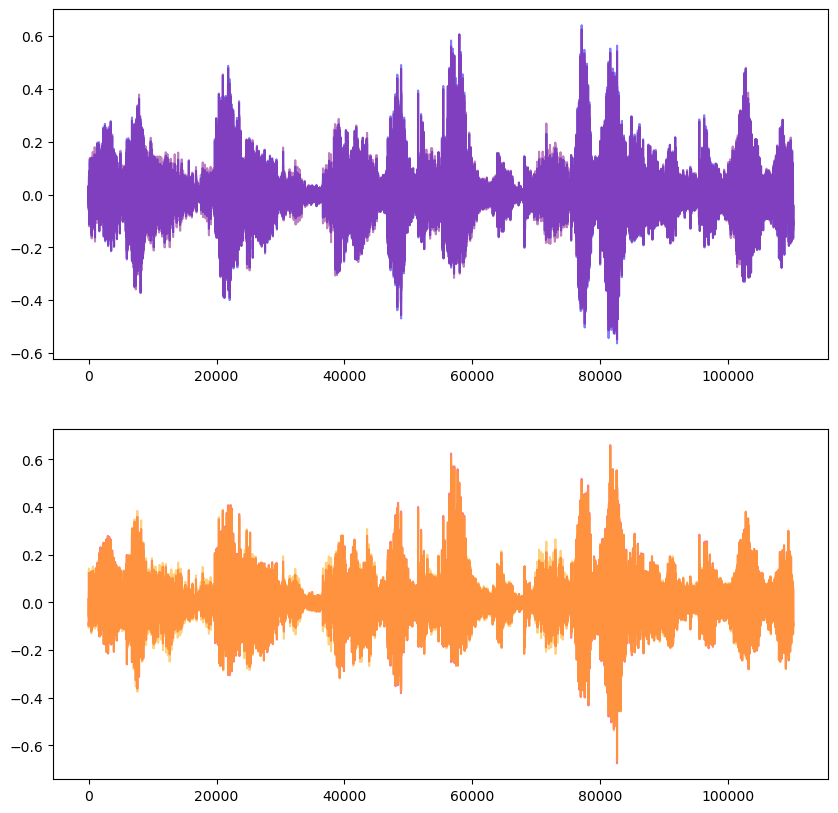

In [11]:
#### Plot left and right channels separately 
%matplotlib inline
import matplotlib.pyplot as plt 

fig, axs = plt.subplots(2, 1, figsize=(10,10))

axs[0].plot(transform_mixture[0,0].cpu().detach().numpy(), 'b', label='transforms left ch.', alpha=0.5)
axs[0].plot(manual_mixture[0,0].cpu().detach().numpy(), 'purple', label='manual left ch.', alpha=0.5)

axs[1].plot(transform_mixture[0,1].cpu().detach().numpy(), 'r', label='transforms right ch.', alpha=0.5)
axs[1].plot(manual_mixture[0,1].cpu().detach().numpy(), 'orange', label='manual right ch.', alpha=0.5)




### Dummy run model on human-matched setup 

In [5]:
import yaml 

config_path = "config/binaural_attn/word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['num_workers'] = 0
config['hparas']['batch_size'] = 64

ckpt = 'attn_cue_models/word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/checkpoints/epoch=2-step=35108-v1.ckpt'



In [6]:
from src.spatial_attn_lightning import BinauralAttentionModule

model = BinauralAttentionModule.load_from_checkpoint(ckpt, config=config)

model = model.eval().cuda()
coch_gram = model.coch_gram.cuda()

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
Compiling model...


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [7]:

from corpus.binaural_swc_currated_pd import SWCHumanExperimentStimDataset

print("Using textures as background noise")
texture_dataset = SpeechAndTextureTestSet(file_path='/om/user/imgriff/datasets/speech_in_synthetic_textures/separated_sources/stim.hdf5',
                    separated_signals=True,
                    symmetric_distractor=False) # only need one 



model_in_sr = 44100
dataset = SWCHumanExperimentStimDataset(path='/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl',
                                        run_all_stim=True,
                                        sr=model_in_sr)
    # elif args.texture_distractor:
# cue, fg, bg, bg_2, label, dist_word_label, dist_word_label2, stim_ixs = dataset[0]

dataloader = torch.utils.data.DataLoader(dataset, batch_size=config['hparas']['batch_size'], shuffle=False, num_workers=config['num_workers'])


Using textures as background noise


In [8]:
def get_texture_egs(texture_dataset):
    ix = np.random.randint(len(texture_dataset))
    _, _, texture_signal, _, texture_label = texture_dataset[ix]

    # texture_labels.append(texture_label)
    texture_signals = torch.from_numpy(texture_signal).unsqueeze(0)
    return texture_signals, texture_label

In [9]:
#### Setup test loc

### Get eg distractor locations :

dist_locs = [[0,40], [10, 40], [350, 40]]
brir_ixs= []
for coords in dist_locs:
    df_row = only14_manifest[(only14_manifest['src_azim'] == coords[0]) & (only14_manifest['src_elev'] == coords[1])]
    brir_ixs.append(df_row['index_brir'].values[0])


delta = 10 

all_brir_ixs = only14_manifest.index_brir.values
with h5py.File(h5_path, mode='r') as brir_h5:
    all_brirs = brir_h5['brir'][all_brir_ixs]
# flip sizing 
n_locs, n_taps, n_channels = all_brirs.shape
print(f"Loaded {n_locs} BRIRs with {n_taps} taps and {n_channels} channels")

texture_brir  = SpatializeAllLocs(all_brirs[::4], model_sr=model_in_sr).cuda()

tar_brir = Spatialize(all_brirs[brir_ixs[0]], model_sr=model_in_sr).cuda()
dist_brir_l = Spatialize(all_brirs[brir_ixs[1]], model_sr=model_in_sr).cuda()
dist_brir_r = Spatialize(all_brirs[brir_ixs[2]], model_sr=model_in_sr).cuda()





Loaded 504 BRIRs with 22050 taps and 2 channels
Loaded 126 BRIRs with 22050 taps and 2 channels
(2, 1, 126, 22050)


In [10]:
## Set test params 

# texture transform 
texture_db = 40
rms_texture_level = db_to_rms(texture_db)
set_texture_level = at.BinauralRMSNormalizeForegroundAndBackground(rms_texture_level).cuda()


# manually set distractors to level, then spatialize, then add 
dist_level = 65 - 10*np.log10(2) # 2 is the number of distractors
dist_rms = db_to_rms(dist_level)
set_dist_level = at.BinauralRMSNormalizeForegroundAndBackground(dist_rms).cuda()

SNR = 0
target_rms = db_to_rms(65 + SNR)
set_target_level = at.BinauralRMSNormalizeForegroundAndBackground(target_rms).cuda()


# set cue transform 
cue_rms = db_to_rms(65)
set_cue_level = at.BinauralRMSNormalizeForegroundAndBackground(cue_rms).cuda()


In [11]:
Audio(texture_signal, rate=44100)

In [12]:
### Sim main loop 

accuracies = []
confusions = []
pred_list = []
true_word_int = []
stim_ix_list = []
texture_list = []

# texture_dataloader = iter(texture_dataloader)
with torch.no_grad():
    for batch in tqdm(dataloader):
        cue, fg, bg, bg_2, label, dist_word_label, dist_word_label2, stim_ixs = batch

        # set levels then spatialize 
        cue, _ = set_cue_level(cue, None)
        target, _ = set_target_level(fg, None)
        bg_1, bg_2 = set_dist_level(bg, bg_2)

        # spatialize signals 
        cue = tar_brir(cue.cuda())
        target = tar_brir(target.cuda())
        bg_1 = dist_brir_l(bg_1.cuda())
        bg_2 = dist_brir_r(bg_2.cuda())

        # get texture stim 
        # _, _, texture_signal, _, texture_label = next(texture_dataloader)
        texture_signal, texture_label = get_texture_egs(texture_dataset)
        texture_list.extend([texture_label] * fg.shape[0])
        spatial_texutre = texture_brir(texture_signal.cuda())
        spatial_texture, _ = set_texture_level(spatial_texutre, None)
    
        # combine signals 
        mixture = target + bg_1 + bg_2 + spatial_texture   
        # break
        # get cochleagrams 
        cue, mixture = coch_gram(cue, mixture)

        logits = model(cue, mixture, None)
        preds = logits.softmax(dim=-1).argmax(dim=-1).cpu().detach().numpy().astype('int')
        true_word = label.numpy().astype('int')
        accuracy = (preds == true_word).astype('int')
        accuracies.append(accuracy)
        pred_list.append(preds)
        true_word_int.append(true_word)

        # log confusions 
        dist_word_label = dist_word_label.numpy().astype('int')
        dist_word_label2 = dist_word_label2.numpy().astype('int')
        # confusion made if preds == dist_word_label or dist_word_label2
        cons_1 = (preds == dist_word_label).astype('int')
        cons_2 = (preds == dist_word_label2).astype('int')
        cons = np.bitwise_or(cons_1, cons_2) # get union of confusions
        confusions.append(cons)


 19%|█▉        | 6/31 [01:14<04:44, 11.37s/it]/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/corpus/binaural_swc_currated_pd.py:141: UserWarning: PySoundFile failed. Trying audioread instead.
  cue_wav, _ = librosa.load(cue_src_fn, sr=self.sr, offset=cue_onset, duration=self.total_dur, dtype=np.float32)
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 97%|█████████▋| 30/31 [05:42<00:11, 11.18s/it]/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torch/overrides.py:110: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  torch.has_cuda,
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torch/overrides.py:111: UserWarning: 'has_cudnn' is deprecated

In [44]:
for _ in range(100):
    texture_ixs = np.sort(np.random.randint(len(texture_dataset), size=config['hparas']['batch_size']))
    _, _, texture_signal, _, texture_label = texture_dataset[texture_ixs]